In [6]:
from typing import Any, Callable, Dict, Sequence, Tuple, Union
from PIL import Image
import os
import random

import numpy as np

import torch 
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms
from torchmetrics.classification import Accuracy
import pytorch_lightning as pl

from astroNN.datasets import load_galaxy10
from astroNN.datasets.galaxy10 import galaxy10cls_lookup
from tensorflow.keras import utils

import matplotlib.pyplot as plt

In [7]:
# Load images and labels (will download automatically the first time)
# First time downloading location will be ~/.astroNN/datasets/
images, labels = load_galaxy10()

# Convert the labels to categorical 10 classes
labels_categorical = utils.to_categorical(labels, 10)

# Convert to desirable type
labels_categorical = labels_categorical.astype(np.float32)
images = images.astype(np.float32)

C:\Users\nikhi\.astroNN\datasets\Galaxy10_DECals.h5 was found!


In [9]:
# Print some basic information
n, width, height, n_colors = images.shape
print(f'Number of data points: {n}')
print(f'Width of images: {width}')
print(f'Height of images: {height}')
print(f'Number of colors: {n_colors}')

Number of data points: 17736
Width of images: 256
Height of images: 256
Number of colors: 3


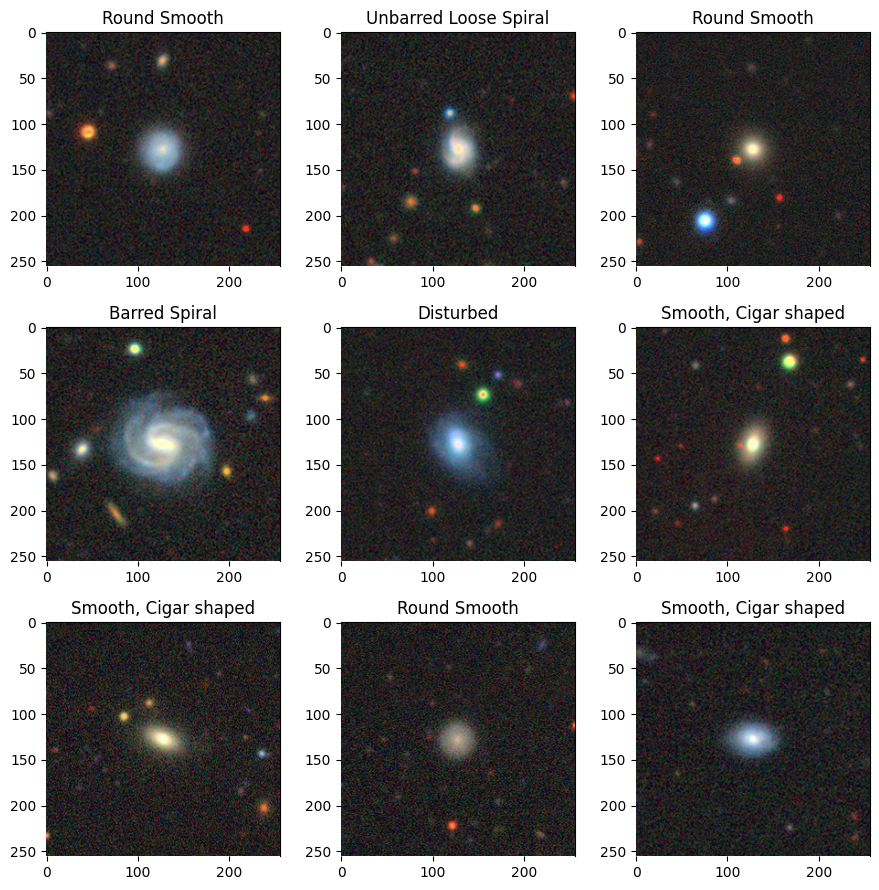

In [10]:
# Plot some images with labels
f, axes = plt.subplots(3, 3, figsize=(9, 9))

rand = random.sample(range(n), 9)
for r, ax in zip(rand, axes.ravel()):

    image, label = images[r], labels[r]
    ax.imshow(image / 255.0)
    label_name = galaxy10cls_lookup(label)
    ax.set_title(label_name)

    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.tight_layout()

In [5]:
%%time
%run train.py --overfit_batches 1 --batch_size 8 --max_epochs 1

C:\Users\nikhi\.astroNN\datasets\Galaxy10_DECals.h5 was found!


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
`Trainer(overfit_batches=1)` was configured so 1 batch will be used.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode 
--------------------------------------------------------
0 | model    | CNN                | 552 K  | train
1 | loss_fn  | CrossEntropyLoss   | 0      | train
2 | accuracy | MulticlassAccuracy | 0      | train
--------------------------------------------------------
552 K     Trainable params
0         Non-trainable params
552 K     Total params
2.209     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=2` reached.


CPU times: total: 29.2 s
Wall time: 26.5 s
